In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Electric: hourly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

# --- Meteorological: hourly observations ---
WEATHER_COLS = ["temp", "rhum", "prcp", "wspd", "pres", "wdir"]
met1 = pd.read_csv("data/meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met2 = pd.read_csv("data/meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met = pd.concat([met1, met2], ignore_index=True).sort_values("time").reset_index(drop=True)

# --- Merge on hour, then resample to daily ---
df_hourly = pd.merge(elec.rename(columns={"timestamp": "time"}), met, on="time", how="inner")
df_hourly = df_hourly.sort_values("time").reset_index(drop=True)

df = (
    df_hourly.set_index("time")
    .resample("D")
    .agg(
        kwh=("kwh", "sum"),
        temp=("temp", "mean"),
        temp_min=("temp", "min"),
        temp_max=("temp", "max"),
        rhum=("rhum", "mean"),
        prcp=("prcp", "sum"),
        wspd=("wspd", "mean"),
        pres=("pres", "mean"),
        wdir=("wdir", "mean")
    )
    .reset_index()
)

print(f"Daily range: {df['time'].min().date()} → {df['time'].max().date()}")
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Daily range: 2022-01-01 → 2026-03-31
Rows: 1,551  |  Columns: ['time', 'kwh', 'temp', 'temp_min', 'temp_max', 'rhum', 'prcp', 'wspd', 'pres', 'wdir']


,time,kwh,temp,temp_min,temp_max,rhum,prcp,wspd,pres,wdir
0,2022-01-01,34.262,2.575000,1.1,5.6,98.666667,3.6,0.283333,1012.554167,4.250
1,2022-01-02,47.032,2.691667,0.6,3.9,96.833333,1.4,3.175000,1003.237500,77.750
2,2022-01-03,48.584,-5.370833,-8.3,0.0,63.666667,0.0,5.866667,1018.412500,156.750
3,2022-01-04,56.612,-9.304167,-14.4,-3.9,57.333333,0.0,5.308333,1024.845833,171.000
4,2022-01-05,43.300,-2.520833,-8.3,8.3,91.458333,5.9,3.250000,1018.620833,69.625


In [2]:
# --- Time features ---
df["dayofweek"] = df["time"].dt.dayofweek
df["month"]     = df["time"].dt.month

# --- HDD (base 65°F) ---
df["temp_f"] = df["temp"] * 9 / 5 + 32
df["hdd"]    = np.maximum(0, 65 - df["temp_f"])

# --- Lag features ---
df["temp_yesterday"] = df["temp"].shift(1)
df["temp_3day"]      = df["temp"].shift(1).rolling(3).mean()
df["hdd_yesterday"]  = df["hdd"].shift(1)
df["hdd_3day"]       = df["hdd"].shift(1).rolling(3).mean()
df["kwh_yesterday"]  = df["kwh"].shift(1)

n_rows = len(df.index)
df = df.dropna(axis=0)
print(f'Dropped: {(n_rows - len(df.index))/n_rows:0.2%} of rows')
df.head()

Dropped: 0.52% of rows


,time,kwh,temp,temp_min,temp_max,rhum,prcp,wspd,pres,wdir,dayofweek,month,temp_f,hdd,temp_yesterday,temp_3day,hdd_yesterday,hdd_3day,kwh_yesterday
3,2022-01-04,56.612,-9.304167,-14.4,-3.9,57.333333,0.0,5.308333,1024.845833,171.000000,1,1,15.2525,49.7475,-5.370833,-0.034722,42.6675,33.0625,48.584
4,2022-01-05,43.300,-2.520833,-8.3,8.3,91.458333,5.9,3.250000,1018.620833,69.625000,2,1,27.4625,37.5375,-9.304167,-3.994444,49.7475,40.1900,56.612
5,2022-01-06,25.369,1.837500,-2.8,5.6,87.666667,0.0,3.400000,1005.254167,111.875000,3,1,35.3075,29.6925,-2.520833,-5.731944,37.5375,43.3175,43.300
6,2022-01-07,39.226,-2.383333,-3.3,-1.1,88.958333,7.4,5.375000,1008.795833,130.916667,4,1,27.7100,37.2900,1.837500,-3.329167,29.6925,38.9925,25.369
7,2022-01-08,83.615,-6.316667,-11.1,-2.8,61.166667,0.0,8.791667,1022.991667,250.708333,5,1,20.6300,44.3700,-2.383333,-1.022222,37.2900,34.8400,39.226


In [3]:
def cyclical_encode(values, period):
    sin = np.sin(2 * np.pi * values / period)
    cos = np.cos(2 * np.pi * values / period)
    return sin, cos

df["dayofweek_sin"], df["dayofweek_cos"] = cyclical_encode(df["dayofweek"], 7)
df["month_sin"],     df["month_cos"]     = cyclical_encode(df["month"], 12)
df["wdir_sin"], df["wdir_cos"] = cyclical_encode(df["wdir"], 360)

In [4]:
FEATURE_COLS = [
    'temp',
    'temp_yesterday',
    'temp_3day',
    'hdd',
    'hdd_yesterday',
    'hdd_3day',
    'rhum',
    'prcp',
    'wspd',
    'kwh_yesterday'
    #'pres',
    #'dayofweek_sin', 'dayofweek_cos',
    #'month_sin', 'month_cos',
    #'wdir_sin', 'wdir_cos'
]

TARGET_COL = "kwh"

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train_s.shape}")
print(f"X_test shape:  {X_test_s.shape}")
print(f"y_train: mean={y_train.mean():.3f} kWh, std={y_train.std():.3f}")
print(f"y_test:  mean={y_test.mean():.3f} kWh, std={y_test.std():.3f}")

Features:      ['temp', 'temp_yesterday', 'temp_3day', 'hdd', 'hdd_yesterday', 'hdd_3day', 'rhum', 'prcp', 'wspd', 'kwh_yesterday']
X_train shape: (1157, 10)
X_test shape:  (386, 10)
y_train: mean=34.449 kWh, std=22.683
y_test:  mean=41.649 kWh, std=23.987


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_s, y_train)

pred_kwh = lr.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, pred_kwh))
r2   = r2_score(y_test, pred_kwh)

print(f"Linear Regression | R²={r2:.3f}  RMSE={rmse:.2f} kWh")

# Coefficients
coef_df = pd.DataFrame({"feature": FEATURE_COLS, "coef": lr.coef_}).sort_values("coef", key=abs, ascending=False)
print(f"\nIntercept: {lr.intercept_:.3f} kWh")
print(coef_df.to_string(index=False))

Linear Regression | R²=0.832  RMSE=9.82 kWh

Intercept: 34.449 kWh
       feature       coef
           hdd  35.711599
          temp  17.213387
 hdd_yesterday -13.852327
 kwh_yesterday   9.957193
temp_yesterday  -8.027193
     temp_3day   4.198312
      hdd_3day   2.283275
          prcp   0.918597
          wspd  -0.612024
          rhum  -0.445076


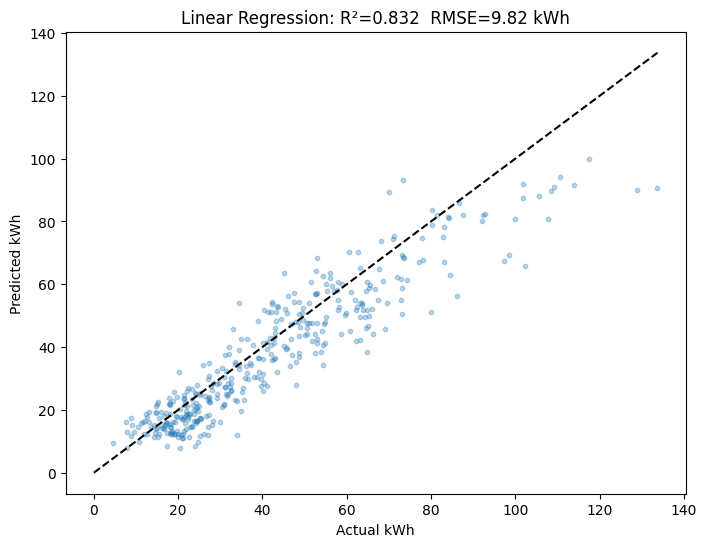

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_kwh, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'k--')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title(f'Linear Regression: R²={r2:.3f}  RMSE={rmse:.2f} kWh')
plt.show()